### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)


In [3]:
graph_builder

In [4]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage, HumanMessage,AIMessage
import os
from dotenv import load_dotenv


load_dotenv()

model = ChatOpenAI(
    model="prism-ml/ternary-bonsai-2-27b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    max_tokens=1000,
)

In [5]:
def chatbot(state: State):
    return {'messages': [model.invoke(state['messages'])]}
   

In [6]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

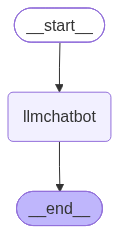

In [7]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response=graph.invoke({"messages":"Hi"})
response["messages"][-1].content

'\n\nHi! How can I help you today?'

In [9]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)



Hi! I'm doing well, thank you. How are you?


### Chatbot With Tool

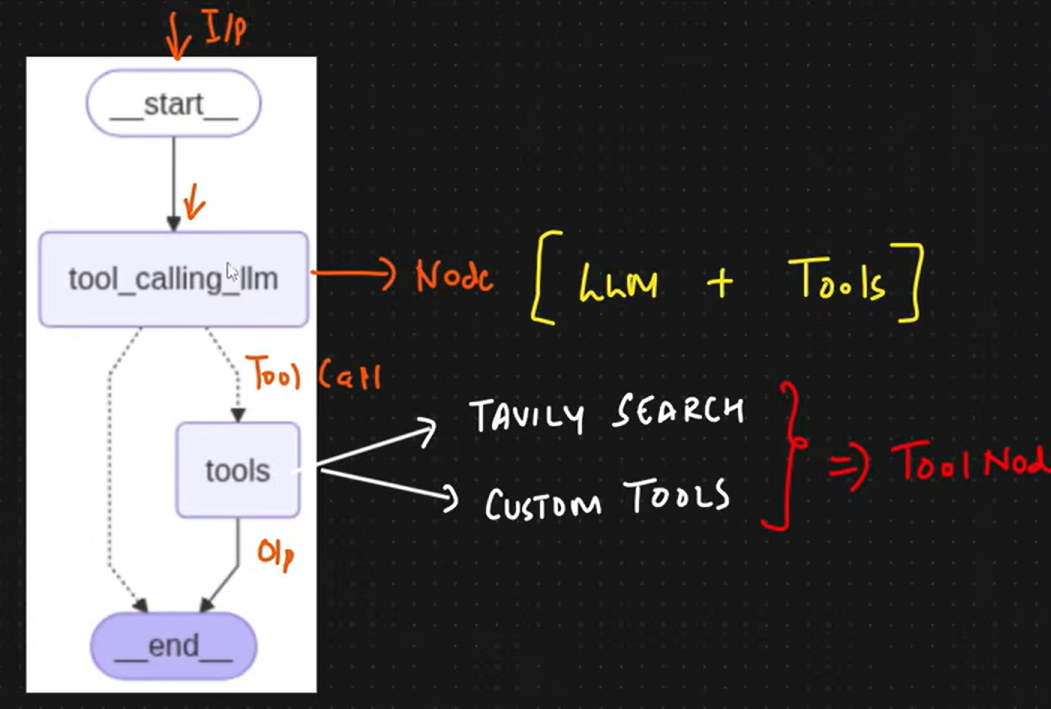

In [11]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.95386744,
   'raw_content': None,
   'id': '70565d-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? | IBM'

In [12]:
# custom Function
def multiply(a:int,b:int)->int:
    """M ultiply a and b

    Args:
        a (int): first number
        b (int): second number
    """
    return a * b
    

In [13]:
tools=[tool,multiply]

In [17]:
llm_with_tools=model.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2', 'langchain-openai': '1.6.6'}}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000022BC3091BE0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000022BC3092660>, root_client=<openai.OpenAI object at 0x0000022BC3091400>, root_async_client=<openai.AsyncOpenAI object at 0x0000022BC30923C0>, model_name='prism-ml/ternary-bonsai-2-27b', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1', max_tokens=1000, stream_chunk_timeout=120.0), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, t

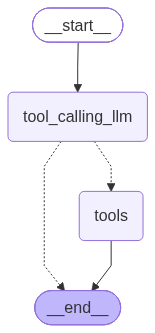

In [18]:
# Creating state graph and using the llm_with_tools model

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Node Definitiom
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

# Graph
builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node('tools',ToolNode(tools))

# Adding edges
# START → LLM
builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    'tool_calling_llm',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
 
    tools_condition
)  
builder.add_edge('tools',END)

#compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response=graph.invoke({"messages":"What is the recent ai news?"})

In [20]:
response["messages"][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.brief.news/ai", "title": "AI News: The Latest Updates and Advancements in AI from Brief", "content": "Meta Platforms is set to invest up to $145 billion in 2026 to bolster its AI capabilities, following a major stake acquisition in Scale AI and the launch of its successful Muse AI agent. With Alexandr Wang at the helm of its Superintelligence Labs, Meta\'s aggressive AI strategy aims to secure a long-term competitive edge despite skepticism over ROI.\\n\\nNVIDIA unveils the Open Agent Safety Platform, integrating Arm-compatible compute with Arm-based DPUs for a unified security framework in AI and cloud ecosystems. The platform, featuring OpenShell and Sentry, aims to establish a seamless security model across Arm-powered infrastructures, underscoring Arm\'s pivotal role in secure, scalable agentic AI. [...] AI is revolutionizing crop breeding, with companies like Av

In [21]:
for i in response["messages"]:
    print(i.pretty_print())

================================ Human Message =================================

What is the recent ai news?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_C7F7187C788541DC9B66F7B6)
 Call ID: call_C7F7187C788541DC9B66F7B6
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: week
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.brief.news/ai", "title": "AI News: The Latest Updates and Advancements in AI from Brief", "content": "Meta Platforms is set to invest up to $145 billion in 2026 to bolster its AI capabilities, following a major stake acquisition in Scale AI and the launch of its successful Muse AI agent. With Alexandr Wang at the helm of its Superintelligence Labs, Meta's aggressive AI strateg

In [33]:
response=graph.invoke({"messages":"What is 2 multiplied by 3?"})

In [22]:
for i in response["messages"]:
    print(i.pretty_print())

================================ Human Message =================================

What is the recent ai news?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_C7F7187C788541DC9B66F7B6)
 Call ID: call_C7F7187C788541DC9B66F7B6
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: week
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.brief.news/ai", "title": "AI News: The Latest Updates and Advancements in AI from Brief", "content": "Meta Platforms is set to invest up to $145 billion in 2026 to bolster its AI capabilities, following a major stake acquisition in Scale AI and the launch of its successful Muse AI agent. With Alexandr Wang at the helm of its Superintelligence Labs, Meta's aggressive AI strateg

In [35]:
response=graph.invoke({"messages":"What is 2 multiplied by 3 and then add 5?"})

In [36]:
for i in response["messages"]:
    print(i.pretty_print())

================================ Human Message =================================

What is 2 multiplied by 3 and then add 5?
None
================================== Ai Message ==================================



11

Here's the breakdown:
- First, 2 × 3 = 6
- Then, 6 + 5 = 11
None


In [38]:
response=graph.invoke({"messages":"what is the recent ai news and what is 2 multiplied by 3?"})
for i in response["messages"]:
    print(i.pretty_print())

================================ Human Message =================================

what is the recent ai news and what is 2 multiplied by 3?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_05292AF11F2F4F0B8A6B8D09)
 Call ID: call_05292AF11F2F4F0B8A6B8D09
  Args:
    query: AI news artificial intelligence developments
    search_depth: advanced
    time_range: month
    topic: news
  multiply (call_8958EFD882E541AFA42D6296)
 Call ID: call_8958EFD882E541AFA42D6296
  Args:
    a: 2
    b: 3
None
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news artificial intelligence developments", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=UGFlczPUn94", "title": "Tech companies sign accord to ‘self-police’ AI development, Trump says", "content": "### Transcript\n[0:01] Welcome back into live now 

In [ ]:
'''To make it iterative we are going to use ReAct Architecture. The ReAct architecture allows the model to reason and act 
in an iterative manner, enabling it to handle complex tasks that require multiple steps of reasoning and action. This is 
particularly useful for tasks that involve tool usage, as the model can decide when to use a tool, interpret the results, 
and then continue reasoning based on those results.'''

### ReAct Agent Architecture


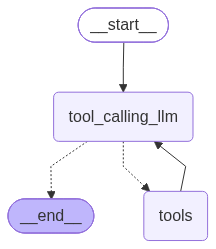

In [23]:
# Creating state graph and using the llm_with_tools model

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Node Definitiom
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

# Graph
builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node('tools',ToolNode(tools))

# Adding edges
# START → LLM
builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    'tool_calling_llm',
    tools_condition
)  
builder.add_edge('tools','tool_calling_llm')  # Loop back to the LLM node for iterative reasoning
builder.add_edge('tools',END)

#compile the graph
graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))